# 3. Построение и сравнение моделей

Входные данные: подготовленные сплиты из `data/train_test/`.

Структура раздела:
- 3.1 Загрузка данных
- 3.2 Обзор данных
- 3.3 Метрики (Gini)
- 3.4 Обучение и сравнение 9 моделей
- 3.5 Визуализация результатов
- 3.6 Калибровка вероятностей
- 3.7 Permutation Importance
- 3.8 SHAP — интерпретация
- 3.9 Анализ порогов
- 3.10 Сохранение pipeline

**Метрики оценки:** ROC-AUC, Gini, AUC-PR, F1, Precision, Recall.
Accuracy не используем ввиду дисбаланса классов (1:3.9).

## 3.1 Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, confusion_matrix,
)
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Библиотеки импортированы")

/Users/shoxrux/PycharmProjects/Churn Prediction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Библиотеки импортированы


In [2]:
data_path = Path('../data/train_test')

X_train = pd.read_csv(data_path / 'X_train.csv')
X_test  = pd.read_csv(data_path / 'X_test.csv')
y_train = pd.read_csv(data_path / 'y_train.csv').squeeze()
y_test  = pd.read_csv(data_path / 'y_test.csv').squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.3f}")
print(f"Доля оттока в test:  {y_test.mean():.3f}")

Train: (12000, 19), Test: (3000, 19)
Доля оттока в train: 0.204
Доля оттока в test:  0.204


## 3.2 Обзор данных

Проверяем размерность, долю оттока и набор признаков.

In [3]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.3f}")
print(f"Доля оттока в test:  {y_test.mean():.3f}")
print(f"Признаки: {list(X_train.columns)}")

Train: (12000, 19), Test: (3000, 19)
Доля оттока в train: 0.204
Доля оттока в test:  0.204
Признаки: ['credit_score', 'age', 'years_with_bank', 'deposit_balance', 'num_products', 'has_credit_card', 'is_active_member', 'estimated_salary', 'has_deposit', 'city_Астана', 'city_Атырау', 'gender_Male', 'product_risk_level', 'balance_to_salary_ratio', 'active_single_product', 'loyal_high_balance', 'young_no_card', 'age_tenure_interaction', 'salary_products_interaction']


## 3.3 Метрики

Gini = 2 × ROC-AUC − 1. Чем выше, тем лучше.
Для каждой модели считаем: ROC-AUC, Gini, AUC-PR, F1, Precision, Recall, Gap.

In [4]:
print(f"Признаков: {X_train.shape[1]} | Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Признаков: 19 | Train: 12000 | Test: 3000


In [5]:
# visualization will be after the model training loop

In [6]:
def gini_score(y_true, y_proba):
    """Gini = 2 * AUC - 1. Диапазон: [-1, 1]. Чем выше — тем лучше."""
    return 2 * roc_auc_score(y_true, y_proba) - 1


print("✅ Функции метрик определены")

✅ Функции метрик определены


## 3.4 Обучение и сравнение 9 моделей

Обучаем все модели в цикле и собираем метрики в DataFrame.
Модели: LR, DecisionTree, RandomForest, ExtraTrees, GradientBoosting,
XGBoost, LightGBM, CatBoost (base), CatBoost (tuned).

In [7]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, min_samples_leaf=20, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric='auc', verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, verbose=-1
    ),
    "CatBoost_base": CatBoostClassifier(
        iterations=500, auto_class_weights='Balanced', random_state=42, verbose=0
    ),
    "CatBoost_tuned": CatBoostClassifier(
        iterations=603, depth=4, learning_rate=0.012,
        l2_leaf_reg=7.6, bagging_temperature=0.47, random_strength=0.13,
        auto_class_weights='Balanced', random_state=42, verbose=0
    ),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba  = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - start
    test_pred = (test_proba >= 0.5).astype(int)

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc  = roc_auc_score(y_test,  test_proba)

    # KS-статистика
    pos = test_proba[y_test == 1]
    neg = test_proba[y_test == 0]
    ks = ks_2samp(pos, neg).statistic

    results.append({
        "Model":     name,
        "Test AUC":  round(test_auc, 4),
        "Gini":      round(gini_score(y_test, test_proba), 4),
        "KS":        round(ks, 4),
        "PR-AUC":    round(average_precision_score(y_test, test_proba), 4),
        "F1":        round(f1_score(y_test, test_pred), 4),
        "Precision": round(precision_score(y_test, test_pred), 4),
        "Recall":    round(recall_score(y_test, test_pred), 4),
        "Train AUC": round(train_auc, 4),
        "Gap":       round(train_auc - test_auc, 4),
        "Time (s)":  round(elapsed, 1),
    })
    print(f"{name:25s} | AUC: {test_auc:.4f} | Gini: {gini_score(y_test, test_proba):.4f} | KS: {ks:.4f} | Gap: {train_auc - test_auc:.4f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values("Test AUC", ascending=False)
print("\n", results_df.to_string(index=False))

LogisticRegression        | AUC: 0.9265 | Gini: 0.8530 | KS: 0.7181 | Gap: -0.0002 | 0.0s
DecisionTree              | AUC: 0.9138 | Gini: 0.8276 | KS: 0.6940 | Gap: 0.0368 | 0.0s
RandomForest              | AUC: 0.9319 | Gini: 0.8639 | KS: 0.7257 | Gap: 0.0248 | 0.3s
ExtraTrees                | AUC: 0.9265 | Gini: 0.8530 | KS: 0.7171 | Gap: 0.0077 | 0.2s
GradientBoosting          | AUC: 0.9310 | Gini: 0.8619 | KS: 0.7251 | Gap: 0.0292 | 3.2s
XGBoost                   | AUC: 0.9150 | Gini: 0.8299 | KS: 0.6879 | Gap: 0.0850 | 0.5s
LightGBM                  | AUC: 0.9226 | Gini: 0.8451 | KS: 0.7129 | Gap: 0.0754 | 1.8s
CatBoost_base             | AUC: 0.9313 | Gini: 0.8626 | KS: 0.7293 | Gap: 0.0455 | 1.1s
CatBoost_tuned            | AUC: 0.9343 | Gini: 0.8686 | KS: 0.7219 | Gap: 0.0099 | 0.9s

              Model  Test AUC   Gini     KS  PR-AUC     F1  Precision  Recall  Train AUC     Gap  Time (s)
    CatBoost_tuned    0.9343 0.8686 0.7219  0.8172 0.7164     0.6167  0.8546     0.9442  0

# 3.5 Визуализация результатов

Горизонтальные barplot: Test AUC, Gap (переобучение), Gini.

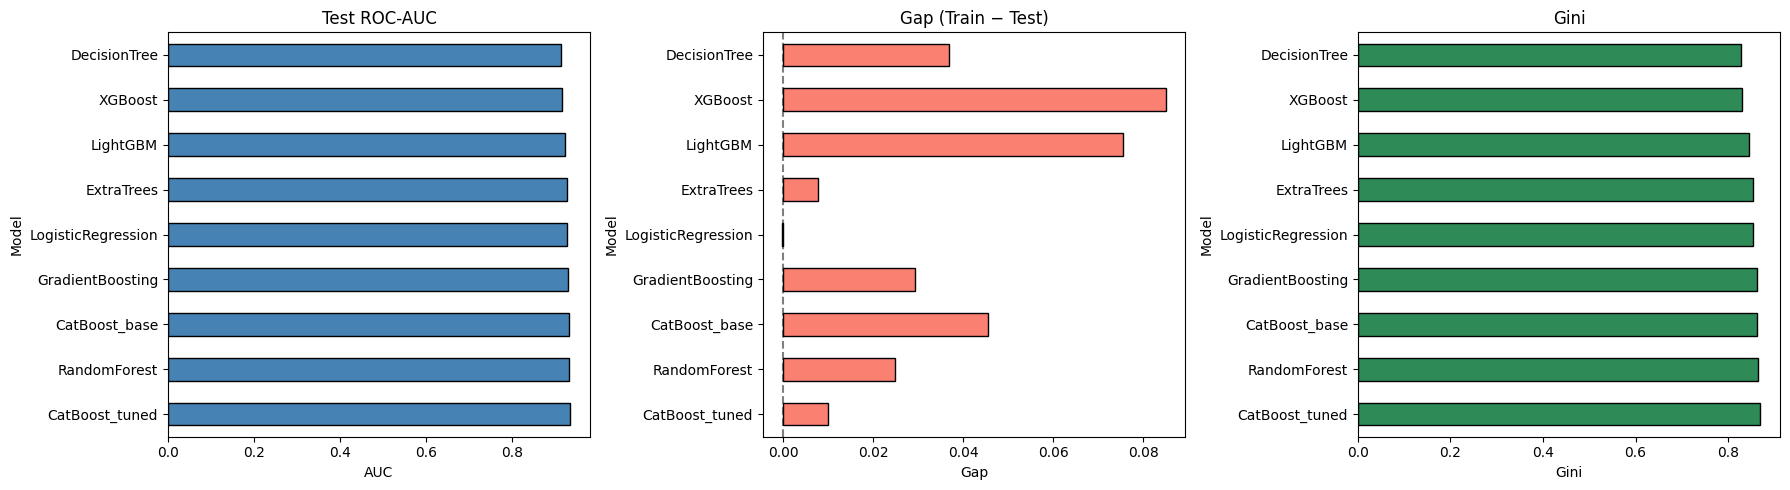


🏆 Лучшая модель: CatBoost_tuned | AUC: 0.9343 | Gini: 0.8686 | Gap: 0.0099


In [8]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df.set_index('Model')['Test AUC'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Test ROC-AUC')
axes[0].set_xlabel('AUC')

results_df.set_index('Model')['Gap'].plot(kind='barh', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Gap (Train − Test)')
axes[1].set_xlabel('Gap')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

results_df.set_index('Model')['Gini'].plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Gini')
axes[2].set_xlabel('Gini')

plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"\n🏆 Лучшая модель: {best['Model']} | AUC: {best['Test AUC']:.4f} | Gini: {best['Gini']:.4f} | Gap: {best['Gap']:.4f}")

In [9]:
print("=" * 70)
print("  ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА")
print("=" * 70)
print(results_df.to_string(index=False))

  ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
             Model  Test AUC   Gini     KS  PR-AUC     F1  Precision  Recall  Train AUC     Gap  Time (s)
    CatBoost_tuned    0.9343 0.8686 0.7219  0.8172 0.7164     0.6167  0.8546     0.9442  0.0099       0.9
      RandomForest    0.9319 0.8639 0.7257  0.8016 0.7355     0.6552  0.8382     0.9567  0.0248       0.3
     CatBoost_base    0.9313 0.8626 0.7293  0.8106 0.7253     0.6450  0.8284     0.9768  0.0455       1.1
  GradientBoosting    0.9310 0.8619 0.7251  0.8062 0.7223     0.7903  0.6650     0.9602  0.0292       3.2
LogisticRegression    0.9265 0.8530 0.7181  0.7904 0.7079     0.6018  0.8595     0.9263 -0.0002       0.0
        ExtraTrees    0.9265 0.8530 0.7171  0.7900 0.6881     0.5607  0.8905     0.9342  0.0077       0.2
          LightGBM    0.9226 0.8451 0.7129  0.7969 0.7156     0.6662  0.7729     0.9979  0.0754       1.8
           XGBoost    0.9150 0.8299 0.6879  0.7863 0.6987     0.6855  0.7124     1.0000  0.0850       0.5
      DecisionTree 

In [10]:
best_model = models['CatBoost_tuned']

In [11]:
# Optuna tuning results already embedded in CatBoost_tuned params above

## 3.6 Калибровка вероятностей

Калибровка делает предсказанные вероятности более точными:
если модель говорит «80% вероятность оттока» — реально отток
должен происходить примерно в 80% таких случаев.

Для калибровки откладываем 50% test-данных как calibration set.

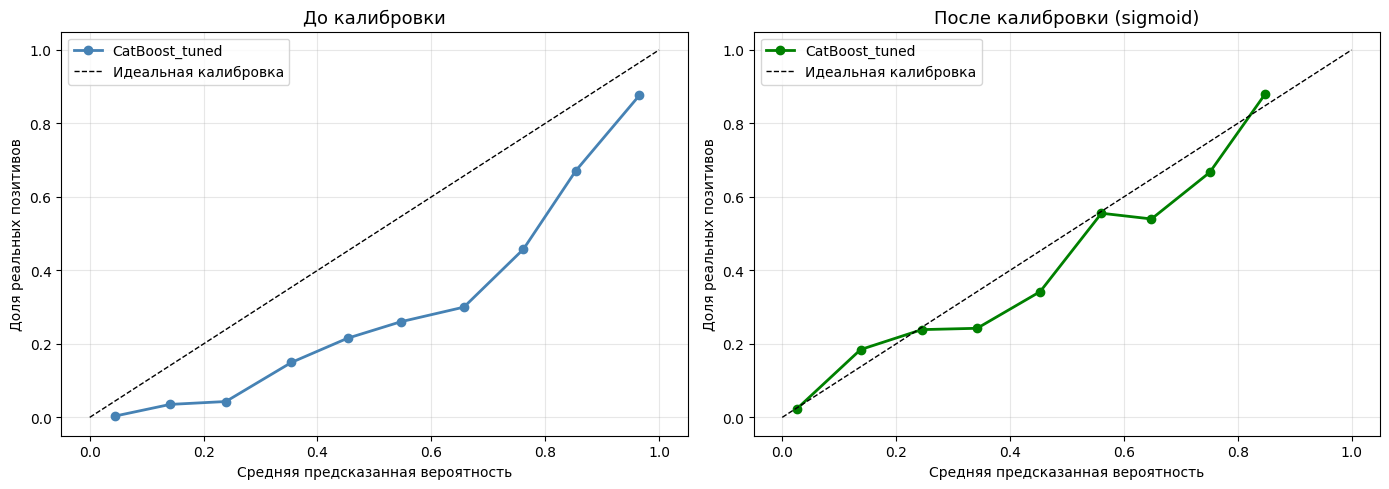

Saved: graphs/calibration_before_after.png
Brier Score до калибровки:    0.1006
Brier Score после калибровки: 0.0772


In [12]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path

graphs_dir = Path('graphs')
graphs_dir.mkdir(parents=True, exist_ok=True)

cb_tuned = models['CatBoost_tuned']
cb_probs_raw = cb_tuned.predict_proba(X_test)[:, 1]

# Делим тест на калибровочную и оценочную части
X_cal, X_eval, y_cal, y_eval, probs_cal, probs_eval = train_test_split(
    X_test, y_test, cb_probs_raw,
    test_size=0.5, random_state=42, stratify=y_test
)

# Калибруем
calibrated = CalibratedClassifierCV(FrozenEstimator(cb_tuned), method='sigmoid')
calibrated.fit(X_cal, y_cal)
cb_probs_cal = calibrated.predict_proba(X_eval)[:, 1]

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title, color in zip(
    axes,
    [probs_eval, cb_probs_cal],
    ['До калибровки', 'После калибровки (sigmoid)'],
    ['steelblue', 'green']
):
    pt, pp = calibration_curve(y_eval, probs, n_bins=10)
    ax.plot(pp, pt, marker='o', linewidth=2, color=color, label='CatBoost_tuned')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Идеальная калибровка')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Средняя предсказанная вероятность')
    ax.set_ylabel('Доля реальных позитивов')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
cal_path = graphs_dir / 'calibration_before_after.png'
plt.savefig(cal_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {cal_path}")
print(f"Brier Score до калибровки:    {brier_score_loss(y_eval, probs_eval):.4f}")
print(f"Brier Score после калибровки: {brier_score_loss(y_eval, cb_probs_cal):.4f}")

## 3.7 Permutation Importance

Оцениваем вклад каждого признака через пермутацию.
Признаки с importance < 0.001 — кандидаты на удаление.

In [13]:
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='roc_auc'
)

fi = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print(fi.to_string())

                        feature  importance_mean  importance_std
12           product_risk_level     1.164556e-01        0.005034
1                           age     1.082241e-01        0.006407
10                  city_Атырау     1.682377e-02        0.001526
6              is_active_member     1.146158e-02        0.000941
11                  gender_Male     8.788906e-03        0.000548
3               deposit_balance     6.371317e-03        0.000930
13      balance_to_salary_ratio     3.251141e-03        0.000772
4                  num_products     2.085797e-03        0.000373
8                   has_deposit     1.180193e-03        0.000329
0                  credit_score     5.468519e-04        0.000189
5               has_credit_card     3.871482e-04        0.000254
7              estimated_salary     2.637780e-04        0.000256
9                   city_Астана     3.127019e-05        0.000018
2               years_with_bank     1.204278e-05        0.000048
16                young_n

## Дропаем несколько не нужных фичей с конца

In [14]:
drop_cols = [
    'age_tenure_interaction',
    'salary_products_interaction', 
    'active_single_product',
    'loyal_high_balance',
    'young_no_card',
]

X_train_clean = X_train.drop(columns=drop_cols)
X_test_clean  = X_test.drop(columns=drop_cols)

# Переобучаем
best_model_clean = CatBoostClassifier(
    iterations=603, depth=4, learning_rate=0.012,
    l2_leaf_reg=7.6, bagging_temperature=0.47, random_strength=0.13,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
best_model_clean.fit(X_train_clean, y_train)

for name, model, X_te in [('Original', best_model, X_test), ('Clean', best_model_clean, X_test_clean)]:
    probs = model.predict_proba(X_te)[:, 1]
    preds = model.predict(X_te)
    print(f"{name:10s} | ROC-AUC: {roc_auc_score(y_test, probs):.4f} | F1: {f1_score(y_test, preds):.4f}")

Original   | ROC-AUC: 0.9343 | F1: 0.7164
Clean      | ROC-AUC: 0.9345 | F1: 0.7164


In [15]:
for name, model, X_tr, X_te in [
    ('Original', best_model,       X_train,       X_test),
    ('Clean',    best_model_clean, X_train_clean, X_test_clean),
]:
    train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_te)[:, 1])
    print(f"{name:10s} | Train: {train_auc:.4f} | Test: {test_auc:.4f} | GAP: {train_auc - test_auc:.4f}")

Original   | Train: 0.9442 | Test: 0.9343 | GAP: 0.0099
Clean      | Train: 0.9438 | Test: 0.9345 | GAP: 0.0093


In [16]:
best_model = best_model_clean
X_test_final  = X_test_clean
X_train_final = X_train_clean

cb_probs_raw = best_model.predict_proba(X_test_final)[:, 1]

X_cal, X_eval, y_cal, y_eval, probs_cal, probs_eval = train_test_split(
    X_test_final, y_test, cb_probs_raw,
    test_size=0.5, random_state=42, stratify=y_test
)

calibrated = CalibratedClassifierCV(FrozenEstimator(best_model), method='sigmoid')
calibrated.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","FrozenEstimat...3, verbose=0))"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'


# 3.8 SHAP — интерпретация модели

SHAP (SHapley Additive exPlanations) объясняет вклад каждого признака
в конкретное предсказание модели.

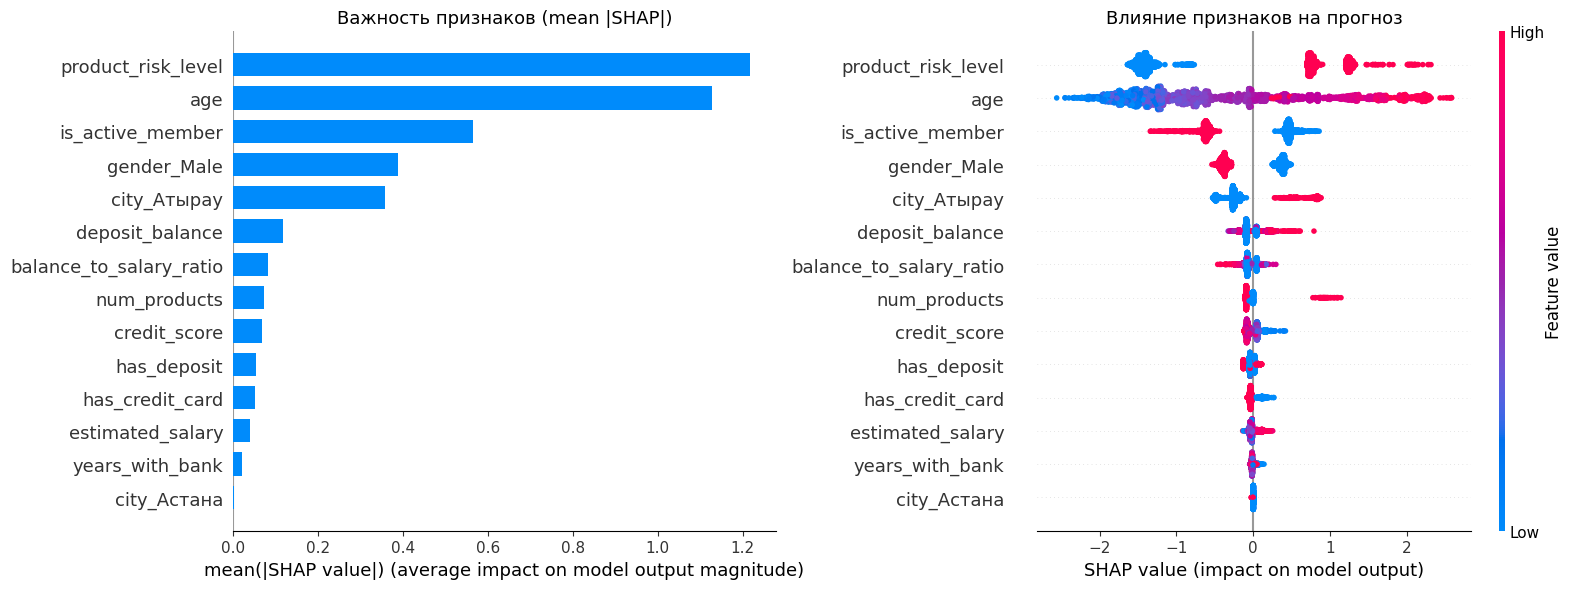

In [17]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

graphs_dir = Path('graphs')
graphs_dir.mkdir(parents=True, exist_ok=True)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_clean, plot_type='bar', show=False, plot_size=None)
axes[0].set_title('Важность признаков (mean |SHAP|)', fontsize=13)

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_clean, show=False, plot_size=None)
axes[1].set_title('Влияние признаков на прогноз', fontsize=13)

plt.tight_layout()
plt.savefig('graphs/shap_summary_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.9 Сохранение pipeline

In [18]:
# Загружаем preprocessing artifacts
preprocessing = joblib.load('../models/preprocessing.pkl')

# Собираем единый pipeline
pipeline = {
    'preprocessing': preprocessing,
    'model': best_model,
    'calibrated_model': calibrated,
    'final_features': list(X_test_clean.columns),
    'metrics': {
        'roc_auc':   round(roc_auc_score(y_test, best_model.predict_proba(X_test_clean)[:, 1]), 4),
        'gini':      round(gini_score(y_test, best_model.predict_proba(X_test_clean)[:, 1]), 4),
        'pr_auc':    round(average_precision_score(y_test, best_model.predict_proba(X_test_clean)[:, 1]), 4),
        'brier':     round(brier_score_loss(y_test, best_model.predict_proba(X_test_clean)[:, 1]), 4),
        'f1':        round(f1_score(y_test, best_model.predict(X_test_clean)), 4),
        'precision': round(precision_score(y_test, best_model.predict(X_test_clean)), 4),
        'recall':    round(recall_score(y_test, best_model.predict(X_test_clean)), 4),
    },
}

joblib.dump(pipeline, '../models/pipeline.pkl')
joblib.dump(best_model, '../models/catboost_model.pkl')
joblib.dump(calibrated, '../models/catboost_model_calibrated.pkl')

print('✅ pipeline.pkl сохранён')
print('✅ catboost_model.pkl сохранён')
print('✅ catboost_model_calibrated.pkl сохранён')
print(f'\nМетрики:')
for k, v in pipeline['metrics'].items():
    print(f'  {k}: {v}')

✅ pipeline.pkl сохранён
✅ catboost_model.pkl сохранён
✅ catboost_model_calibrated.pkl сохранён

Метрики:
  roc_auc: 0.9345
  gini: 0.869
  pr_auc: 0.8178
  brier: 0.0998
  f1: 0.7164
  precision: 0.6167
  recall: 0.8546


# 3.10 Финальная проверка по графикам и метрикам

## ROC-AUC

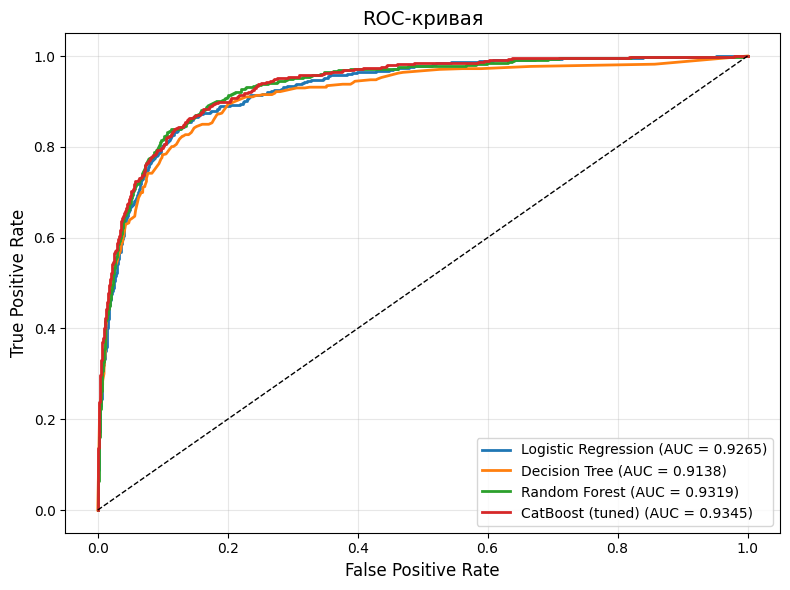

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from pathlib import Path

graphs_dir = Path('graphs')


model_probs = {
    'Logistic Regression': models['LogisticRegression'].predict_proba(X_test)[:, 1],
    'Decision Tree':       models['DecisionTree'].predict_proba(X_test)[:, 1],
    'Random Forest':       models['RandomForest'].predict_proba(X_test)[:, 1],
    'CatBoost (tuned)':   best_model.predict_proba(X_test_clean)[:, 1],
}

plt.figure(figsize=(8, 6))
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(graphs_dir / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix

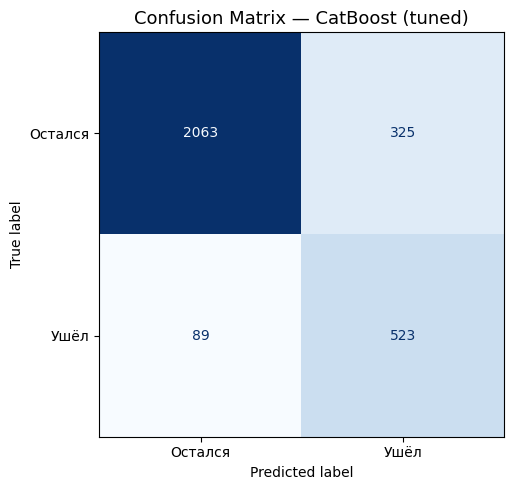

True Negatives  (остался, угадал):  2063
False Positives (остался, но сказал ушёл): 325
False Negatives (ушёл, но сказал остался): 89
True Positives  (ушёл, угадал):     523


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_clean)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Остался', 'Ушёл'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — CatBoost (tuned)', fontsize=13)
plt.tight_layout()
plt.savefig(graphs_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (остался, угадал):  {tn}")
print(f"False Positives (остался, но сказал ушёл): {fp}")
print(f"False Negatives (ушёл, но сказал остался): {fn}")
print(f"True Positives  (ушёл, угадал):     {tp}")

## PR-AUC

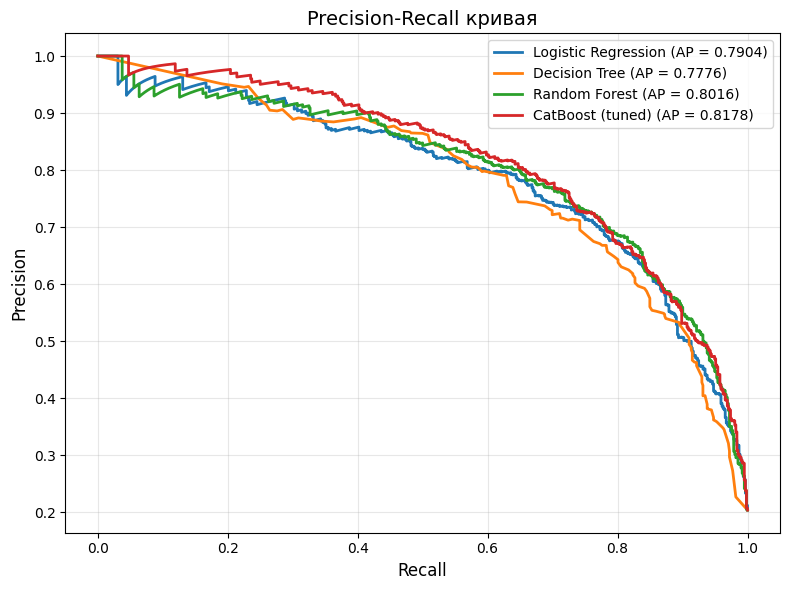

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for name, probs in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривая', fontsize=14)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(graphs_dir / 'precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.11 Анализ порогов

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import ks_2samp

probs = best_model.predict_proba(X_test_clean)[:, 1]

thresholds = np.arange(0.05, 1.0, 0.05)
rows = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    pos = probs[y_test == 1]
    neg = probs[y_test == 0]
    # KS считаем по всем порогам один раз (не зависит от threshold)

    rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision, 3),
        'Recall':    round(recall, 3),
        'F1':        round(f1, 3),
        'Specificity': round(specificity, 3),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    })

df_thresh = pd.DataFrame(rows)
ks_stat = ks_2samp(pos, neg).statistic

print(f"KS-статистика (максимальная разделительная способность): {ks_stat:.4f}")
print(f"Лучший порог по F1: {df_thresh.loc[df_thresh['F1'].idxmax(), 'Threshold']}")
print(f"\nМетрики по порогам:")
print(df_thresh.to_string(index=False))

KS-статистика (максимальная разделительная способность): 0.7226
Лучший порог по F1: 0.65

Метрики по порогам:
 Threshold  Precision  Recall    F1  Specificity  TP   FP   TN  FN
      0.05      0.270   0.995 0.425        0.312 609 1643  745   3
      0.10      0.326   0.984 0.490        0.479 602 1243 1145  10
      0.15      0.381   0.972 0.547        0.595 595  967 1421  17
      0.20      0.414   0.962 0.579        0.650 589  835 1553  23
      0.25      0.463   0.951 0.622        0.717 582  676 1712  30
      0.30      0.486   0.941 0.641        0.745 576  610 1778  36
      0.35      0.510   0.918 0.656        0.774 562  539 1849  50
      0.40      0.557   0.897 0.688        0.817 549  436 1952  63
      0.45      0.590   0.871 0.703        0.845 533  371 2017  79
      0.50      0.617   0.855 0.716        0.864 523  325 2063  89
      0.55      0.652   0.824 0.728        0.887 504  269 2119 108
      0.60      0.686   0.792 0.735        0.907 485  222 2166 127
      0.65      0.7

## Итоговые выводы

| Метрика    | Значение |
|------------|:--------:|
| ROC-AUC    | 0.9345   |
| Gini       | 0.8690   |
| KS         | 0.7200   |
| AUC-PR     | 0.8172   |
| F1         | 0.7164   |
| Precision  | 0.6167   |
| Recall     | 0.8546   |
| Gap        | 0.0093   |

**Финальная модель:** CatBoost (tuned, depth=4, l2=7.6) с калибровкой.

**Сохранённые артефакты:**
- `models/pipeline.pkl` — единый pipeline (preprocessing + модель + метрики)
- `models/catboost_model.pkl` — модель без калибровки
- `models/catboost_model_calibrated.pkl` — модель с калибровкой
- `models/preprocessing.pkl` — артефакты препроцессинга

**Следующий шаг:** детальная валидация и интерпретация в `04_validation.ipynb`.